In [1]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

In [6]:


class MyProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=2,
                         n_obj=2,
                         
                         xl=np.array([-5,-5]),
                         xu=np.array([5,5]))

    def _evaluate(self, X, out, *args, **kwargs):

        x = X[0]
        y = X[1]
        
        f1 = x**2 + y**2
        f2 = (x-1)**2 + (y-1)**2
        out["F"] = [f1,f2]
       


problem = MyProblem()

algorithm = NSGA2(
    n_max_gen = 100,
    pop_size=40,
    n_offsprings=10,
    eliminate_duplicates=True,
    save_history=True
)

In [7]:
res = minimize(problem,
               algorithm,
               
               seed=1,
               save_history=True,
               verbose=True)

X = res.X
F = res.F

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       40 |      5 |             - |             -
     2 |       50 |      5 |  0.000000E+00 |             f
     3 |       60 |      2 |  2.5150979288 |         ideal
     4 |       70 |      3 |  0.0420536646 |         ideal
     5 |       80 |      3 |  0.000000E+00 |             f
     6 |       90 |      4 |  0.0639861390 |         ideal
     7 |      100 |      5 |  0.0179375914 |             f
     8 |      110 |      7 |  0.0486860695 |         ideal
     9 |      120 |      7 |  0.0364733594 |         ideal
    10 |      130 |      8 |  0.0633876026 |             f
    11 |      140 |     10 |  0.0104388069 |         nadir
    12 |      150 |     13 |  0.0102943964 |             f
    13 |      160 |     13 |  0.000000E+00 |             f
    14 |      170 |     14 |  0.0089569427 |             f
    15 |      180 |     15 |  0.0102187983 |         ideal
    16 |      190 |     18 |  0.0030042490 |         nad

In [8]:
res.pop.get("F")[:,0]

array([4.21783198e-07, 1.99669716e+00, 5.20969217e-01, 6.49505261e-01,
       1.82173888e+00, 1.67692339e+00, 9.35407275e-03, 3.44840885e-03,
       3.23433695e-01, 2.69442016e-02, 3.84283483e-01, 7.42292725e-01,
       1.26930535e+00, 8.17702700e-01, 2.84007622e-01, 2.43814327e-01,
       1.73534535e-02, 8.83815394e-01, 9.69278719e-01, 4.59354116e-01,
       1.57989035e+00, 1.34157436e+00, 1.42849777e+00, 1.16435584e+00,
       4.88593637e-02, 1.93447837e+00, 1.50484952e+00, 1.43839783e-01,
       4.34924652e-01, 1.59629968e-01, 1.99880300e-01, 7.23523689e-02,
       6.39525943e-02, 6.82777350e-01, 2.21880753e-01, 1.12896771e+00,
       1.05772714e+00, 1.03456462e-01, 1.02232583e+00, 9.62184357e-02])

In [9]:
print(res.X)
print(res.F)

[[-5.99307372e-04 -2.50227642e-04]
 [ 9.99729619e-01  9.98617971e-01]
 [ 4.80856714e-01  5.38280630e-01]
 [ 5.38171613e-01  5.99897138e-01]
 [ 9.70102024e-01  9.38424712e-01]
 [ 9.41393760e-01  8.89213796e-01]
 [ 2.94183529e-02  9.21337791e-02]
 [-5.99307372e-04  5.87200960e-02]
 [ 3.79006761e-01  4.24013644e-01]
 [ 9.50923453e-02  1.33797038e-01]
 [ 4.76000733e-01  3.97123136e-01]
 [ 6.58860452e-01  5.55153700e-01]
 [ 8.28930107e-01  7.63007355e-01]
 [ 6.45024619e-01  6.33755426e-01]
 [ 3.55388290e-01  3.97123136e-01]
 [ 3.04081678e-01  3.89035552e-01]
 [ 9.50923453e-02  9.11641340e-02]
 [ 6.02700350e-01  7.21503764e-01]
 [ 7.63004337e-01  6.22176101e-01]
 [ 4.80856714e-01  4.77630544e-01]
 [ 8.85583613e-01  8.91982073e-01]
 [ 8.40047287e-01  7.97430192e-01]
 [ 8.08120333e-01  8.80590312e-01]
 [ 7.63004337e-01  7.63007355e-01]
 [ 1.87938528e-01  1.16354945e-01]
 [ 9.93117485e-01  9.73753578e-01]
 [ 8.18508238e-01  9.13725226e-01]
 [ 2.94311754e-01  2.39207806e-01]
 [ 3.79006761e-01  5

In [14]:
vars[:,0]

array([-5.99307372e-04,  9.99729619e-01,  4.80856714e-01,  5.38171613e-01,
        9.70102024e-01,  9.41393760e-01,  2.94183529e-02, -5.99307372e-04,
        3.79006761e-01,  9.50923453e-02,  4.76000733e-01,  6.58860452e-01,
        8.28930107e-01,  6.45024619e-01,  3.55388290e-01,  3.04081678e-01,
        9.50923453e-02,  6.02700350e-01,  7.63004337e-01,  4.80856714e-01,
        8.85583613e-01,  8.40047287e-01,  8.08120333e-01,  7.63004337e-01,
        1.87938528e-01,  9.93117485e-01,  8.18508238e-01,  2.94311754e-01,
        3.79006761e-01,  2.97884534e-01,  3.74404607e-01,  1.87938528e-01,
        8.20501048e-02,  6.19708886e-01,  4.07653596e-01,  7.02191425e-01,
        7.66749673e-01,  1.80714336e-01,  6.65710546e-01,  1.08396071e-01])

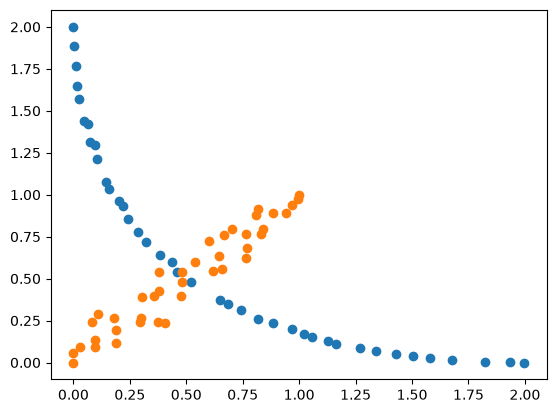

In [17]:
obj1 = res.pop.get("F")[:,0]
obj2= res.pop.get("F")[:,1]
vars = res.pop.get("X")
plt.scatter(obj1,obj2)
plt.scatter(vars[:,0],vars[:,1])